###  **Rail Revenue Intelligence: Analyzing UK Train Ticket Demand and Pricing**
UK train operators handle thousands of passenger journeys daily, but without clear insight into ticket demand, pricing behaviour, route performance, and revenue patterns, it becomes difficult to make effective operational and commercial decisions.

This project explores mock National Rail ticket data from **January to April 2024** to understand how passengers purchase tickets, which routes generate the most activity, how prices vary by ticket class and ticket type, and how demand changes by time of day.

The goal is to use data analytics to uncover patterns that can help train operators improve pricing strategy, manage peak-hour demand, optimize route performance, increase revenue, and enhance passenger experience.


Specific objective of the Analysis
1. Cleaned and Proecessed the dataset to ensure data quality
2. Perform an Exploratory Data Analysis to uncover insights about the business problem
3. Carry out statistical Analysis to summary key metrics
4. Perform Comprehensive analysis - univariate, bivariate and multivariate analysis for uncover insights for
5. Explore visualization of the dataset to communiate findings
6. Documentation, conclusion and recommendation

#### Recommended Analysis 

1. What is the distribution of the train price?
2. Departure station with most train passengers?
3. Which Payment method is the most used?
4. Distribution of the train ticket type: who are our most customers?
5. Top 5 reasons for train delay:What are the main contributing factors?
6. What is the overall status of the journey?
7. What are the most popular routes?
8. What are the peak travel times?
9. How does revenue vary by ticket types and classes?
10. How does train price vary across different times of the day?


#### Step 1: Import Libraires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

#### Step 2: Load Dataset

In [2]:
data_dictionary = pd.read_csv(r"C:\Users\hp\Desktop\Maven Analytic\UK+Train+Rides\railway_data_dictionary.csv")
uk_ride_data =pd.read_csv(r"C:\Users\hp\Desktop\Maven Analytic\UK+Train+Rides\railway.csv")

In [3]:
#looking at the data dictionary
data_dictionary

,Field,Description
0,Transaction ID,Unique identifier for an individual train tick...
1,Date of Purchase,Date the ticket was purchased
2,Time of Purchase,Time the ticket was purchased
3,Purchase Type,Whether the ticket was purchased online or dir...
4,Payment Method,Payment method used to purchase the ticket (Co...
5,Railcard,Whether the passenger is a National Railcard h...
6,Ticket Class,Seat class for the ticket (Standard or First)
7,Ticket Type,When you bought or can use the ticket. Advance...
8,Price,Final cost of the ticket
9,Departure Station,Station to board the train


#### Step 3: Inspecting the dataset

In [4]:
uk_ride_data.head()  ## Taking a look at the the first 5 rows

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [5]:
uk_ride_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [6]:
uk_ride_data['Reason for Delay'].value_counts()

Reason for Delay
Weather               995
Technical Issue       707
Signal Failure        523
Signal failure        447
Staffing              410
Staff Shortage        399
Weather Conditions    377
Traffic               314
Name: count, dtype: int64

#### Step 4: Statistical Analysis

In [7]:
#Statistical analysis for numerical features
uk_ride_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,31653.0,23.4392,29.997628,1.0,5.0,11.0,35.0,267.0


In [8]:
#Statistical analysis for categorical features
uk_ride_data.describe(include ='object').T

,count,unique,top,freq
Transaction ID,31653,31653,da8a6ba8-b3dc-4677-b176,1
Date of Purchase,31653,128,2024-02-02,513
Time of Purchase,31653,24351,08:16:53,6
Purchase Type,31653,2,Online,18521
Payment Method,31653,3,Credit Card,19136
Railcard,10735,3,Adult,4846
Ticket Class,31653,2,Standard,28595
Ticket Type,31653,3,Advance,17561
Departure Station,31653,12,Manchester Piccadilly,5650
Arrival Destination,31653,32,Birmingham New Street,7742


In [9]:
## Let's check for the dimensionality of the data
print(f"row: {uk_ride_data.shape[0]} col: {uk_ride_data.shape[1]}")

row: 31653 col: 18


In [10]:
## Let's check for the dimensionality of the data
numerical_col = ['Price']
categorical_col = ['Transaction ID', 'Date of Purchase', 'Time of Purchase',
       'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class',
       'Ticket Type', 'Departure Station', 'Arrival Destination',
       'Date of Journey', 'Departure Time', 'Arrival Time',
       'Actual Arrival Time', 'Journey Status', 'Reason for Delay',
       'Refund Request']
print(f"row: ({len(numerical_col)}) {numerical_col}, col: ({len(categorical_col)} {categorical_col}")

row: (1) ['Price'], col: (17 ['Transaction ID', 'Date of Purchase', 'Time of Purchase', 'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type', 'Departure Station', 'Arrival Destination', 'Date of Journey', 'Departure Time', 'Arrival Time', 'Actual Arrival Time', 'Journey Status', 'Reason for Delay', 'Refund Request']


#### Step 5:Data Cleaning: Identifying and handling any issues/errors

In [11]:
#Check for duplicates in the entire datset
duplicates = uk_ride_data[uk_ride_data.duplicated(keep =False)]

if duplicates.empty:
    print("Good news, there is no duplicates")
else:
    print("There is duplicates values")

Good news, there is no duplicates


In [12]:
#Let's check for duplicates in the ID columns
duplicates = uk_ride_data[uk_ride_data['Transaction ID'].duplicated(keep =False)]

if duplicates.empty:
    print("Good news, there is no duplicates")
else:
    print("There is duplicates values")

Good news, there is no duplicates


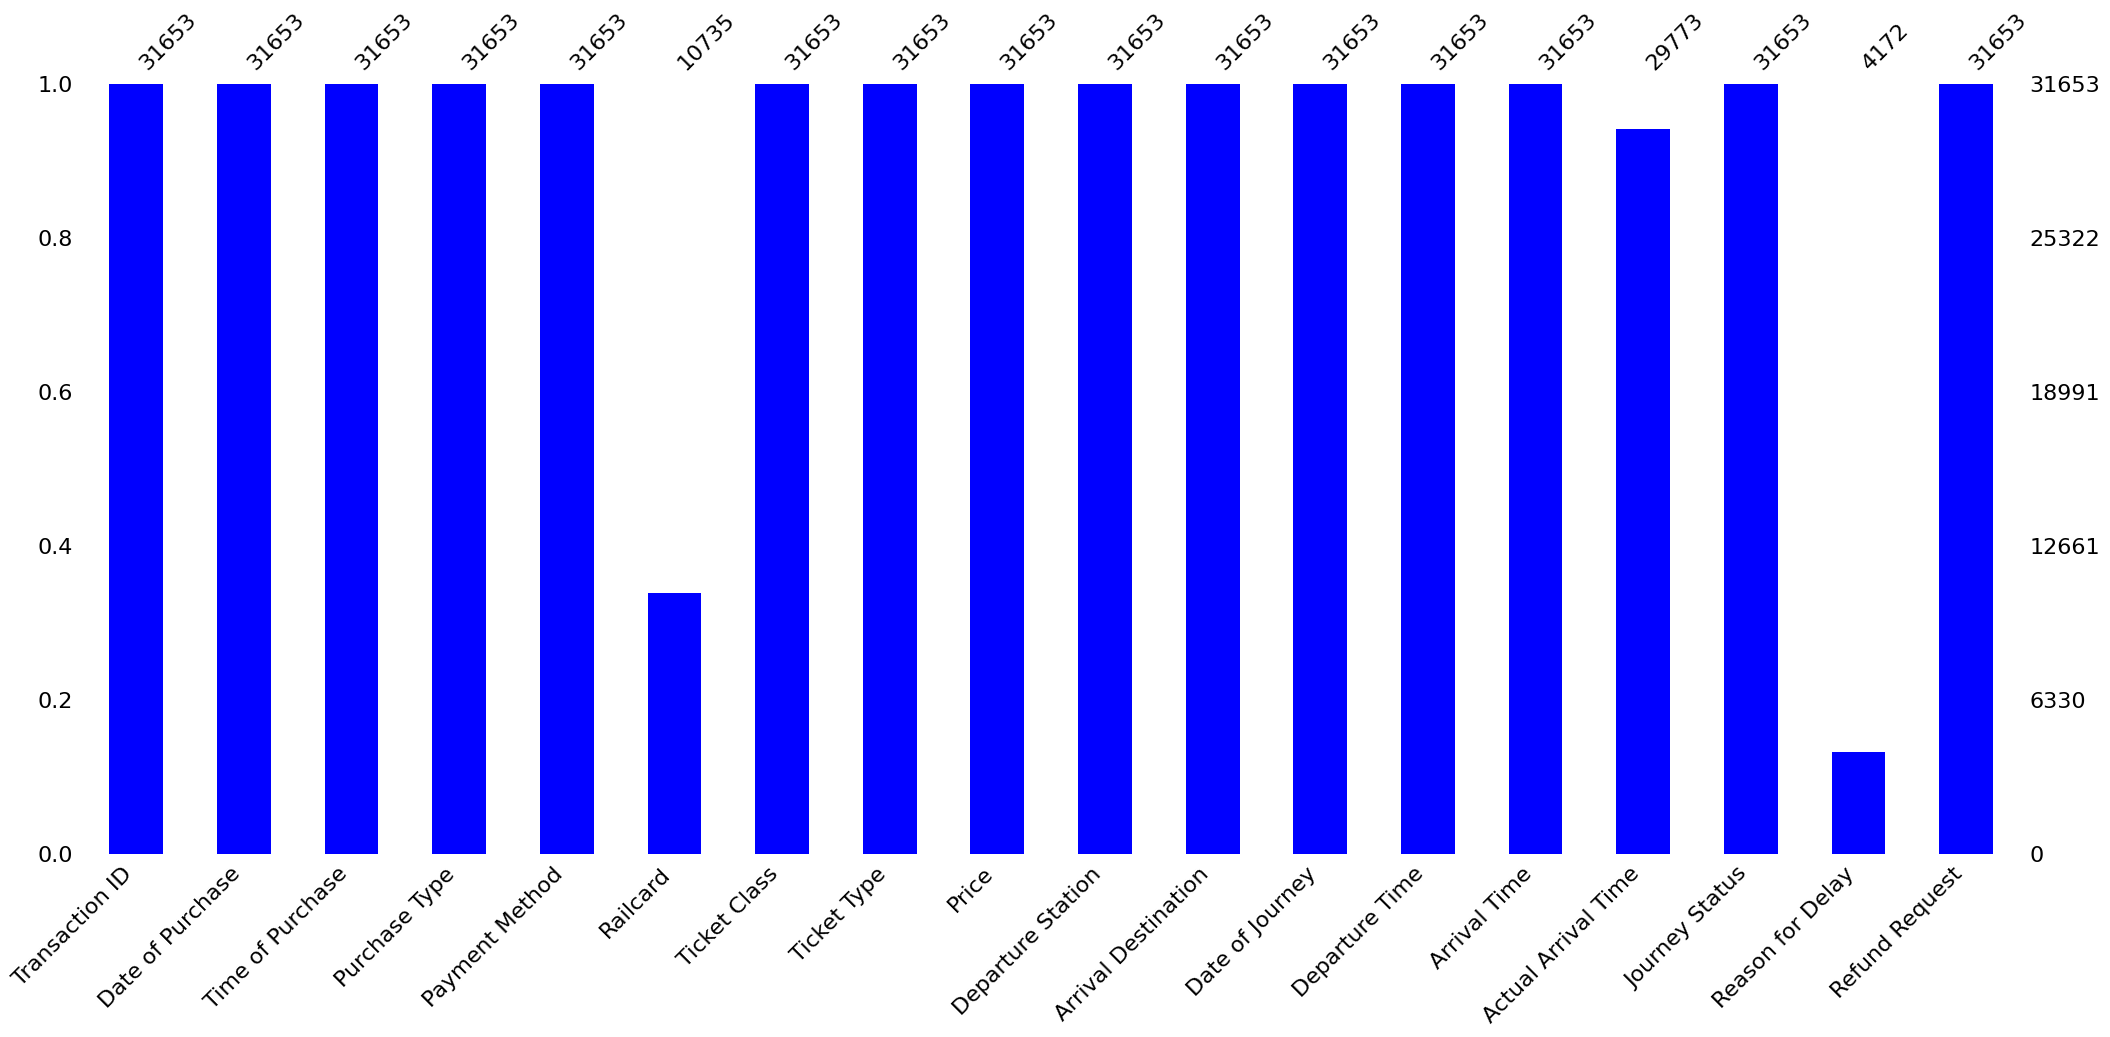

In [13]:
msno.bar(uk_ride_data, color ='blue'); # Visualizing the null values in the dataset

In [14]:
uk_ride_data.isnull().sum()/ len(uk_ride_data) * 100 # looking at the percentage of missing values in the dataset

Transaction ID          0.000000
Date of Purchase        0.000000
Time of Purchase        0.000000
Purchase Type           0.000000
Payment Method          0.000000
Railcard               66.085363
Ticket Class            0.000000
Ticket Type             0.000000
Price                   0.000000
Departure Station       0.000000
Arrival Destination     0.000000
Date of Journey         0.000000
Departure Time          0.000000
Arrival Time            0.000000
Actual Arrival Time     5.939405
Journey Status          0.000000
Reason for Delay       86.819575
Refund Request          0.000000
dtype: float64

In [15]:
# Checking for inconsistencies and whitespace in the dataset

for col in uk_ride_data.columns:
    if col not in ['Price', 'Transaction ID', 'Date of Purchase', 'Time of Purchase', 'Date of Journey', 'Departure Time', 'Arrival Time', 'Actual Arrival Time']:
        print("\n", col)
        print(uk_ride_data[col].unique())


 Purchase Type
['Online' 'Station']

 Payment Method
['Contactless' 'Credit Card' 'Debit Card']

 Railcard
['Adult' nan 'Disabled' 'Senior']

 Ticket Class
['Standard' 'First Class']

 Ticket Type
['Advance' 'Off-Peak' 'Anytime']

 Departure Station
['London Paddington' 'London Kings Cross' 'Liverpool Lime Street'
 'London Euston' 'York' 'Manchester Piccadilly' 'Birmingham New Street'
 'London St Pancras' 'Oxford' 'Reading' 'Edinburgh Waverley'
 'Bristol Temple Meads']

 Arrival Destination
['Liverpool Lime Street' 'York' 'Manchester Piccadilly' 'Reading'
 'London Euston' 'Oxford' 'Durham' 'London St Pancras'
 'Birmingham New Street' 'London Paddington' 'Bristol Temple Meads'
 'Tamworth' 'London Waterloo' 'Sheffield' 'Wolverhampton' 'Leeds'
 'Stafford' 'Doncaster' 'Swindon' 'Nottingham' 'Peterborough' 'Edinburgh'
 'Crewe' 'London Kings Cross' 'Leicester' 'Nuneaton' 'Didcot'
 'Edinburgh Waverley' 'Coventry' 'Wakefield' 'Cardiff Central'
 'Warrington']

 Journey Status
['On Time' 'Delay

We can sport the issue of inconsistencies in the Reason for Delay -Signal Failure vs Signal failure
issue of nan

In [16]:
# Let's resolve this issue
uk_ride_data['Reason for Delay'] = uk_ride_data['Reason for Delay'].str.strip().str.title()
uk_ride_data['Reason for Delay'] =uk_ride_data['Reason for Delay'].str.replace("Signal failure", "Signal Failure")
uk_ride_data['Reason for Delay'] =uk_ride_data['Reason for Delay'].str.replace("Weather Conditions", "Weather")
uk_ride_data['Reason for Delay'] =uk_ride_data['Reason for Delay'].str.replace("Staffing", "Staff Shortage")

In [17]:
uk_ride_data['Reason for Delay'] .value_counts()

Reason for Delay
Weather            1372
Signal Failure      970
Staff Shortage      809
Technical Issue     707
Traffic             314
Name: count, dtype: int64

In [18]:
#Let's look at the issue of null values
uk_ride_data[uk_ride_data.isnull()]

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
uk_ride_data.isnull().sum()/ len(uk_ride_data) * 100 # looking at the percentage of missing values in the dataset

Transaction ID          0.000000
Date of Purchase        0.000000
Time of Purchase        0.000000
Purchase Type           0.000000
Payment Method          0.000000
Railcard               66.085363
Ticket Class            0.000000
Ticket Type             0.000000
Price                   0.000000
Departure Station       0.000000
Arrival Destination     0.000000
Date of Journey         0.000000
Departure Time          0.000000
Arrival Time            0.000000
Actual Arrival Time     5.939405
Journey Status          0.000000
Reason for Delay       86.819575
Refund Request          0.000000
dtype: float64

In [20]:
uk_ride_data['Reason for Delay'] =uk_ride_data['Reason for Delay'].fillna('No reason stated') # let's fill the nan in the reason for the delay as no reason

In [21]:
uk_ride_data['Reason for Delay'].value_counts()

Reason for Delay
No reason stated    27481
Weather              1372
Signal Failure        970
Staff Shortage        809
Technical Issue       707
Traffic               314
Name: count, dtype: int64

In [22]:
#Let then dropna for other columns as we won't use them for analysis
uk_ride_data.dropna(axis =1, inplace =True)

In [23]:
#let check to confirm, it worked
uk_ride_data.isnull().sum()

Transaction ID         0
Date of Purchase       0
Time of Purchase       0
Purchase Type          0
Payment Method         0
Ticket Class           0
Ticket Type            0
Price                  0
Departure Station      0
Arrival Destination    0
Date of Journey        0
Departure Time         0
Arrival Time           0
Journey Status         0
Reason for Delay       0
Refund Request         0
dtype: int64

In [24]:
uk_ride_data.head(2)

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,On Time,No reason stated,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,Delayed,Signal Failure,No


#### Step 6: Data Validation after Cleaning
This help us to ensure everything is okay with our data before going to Visualization and Analysis

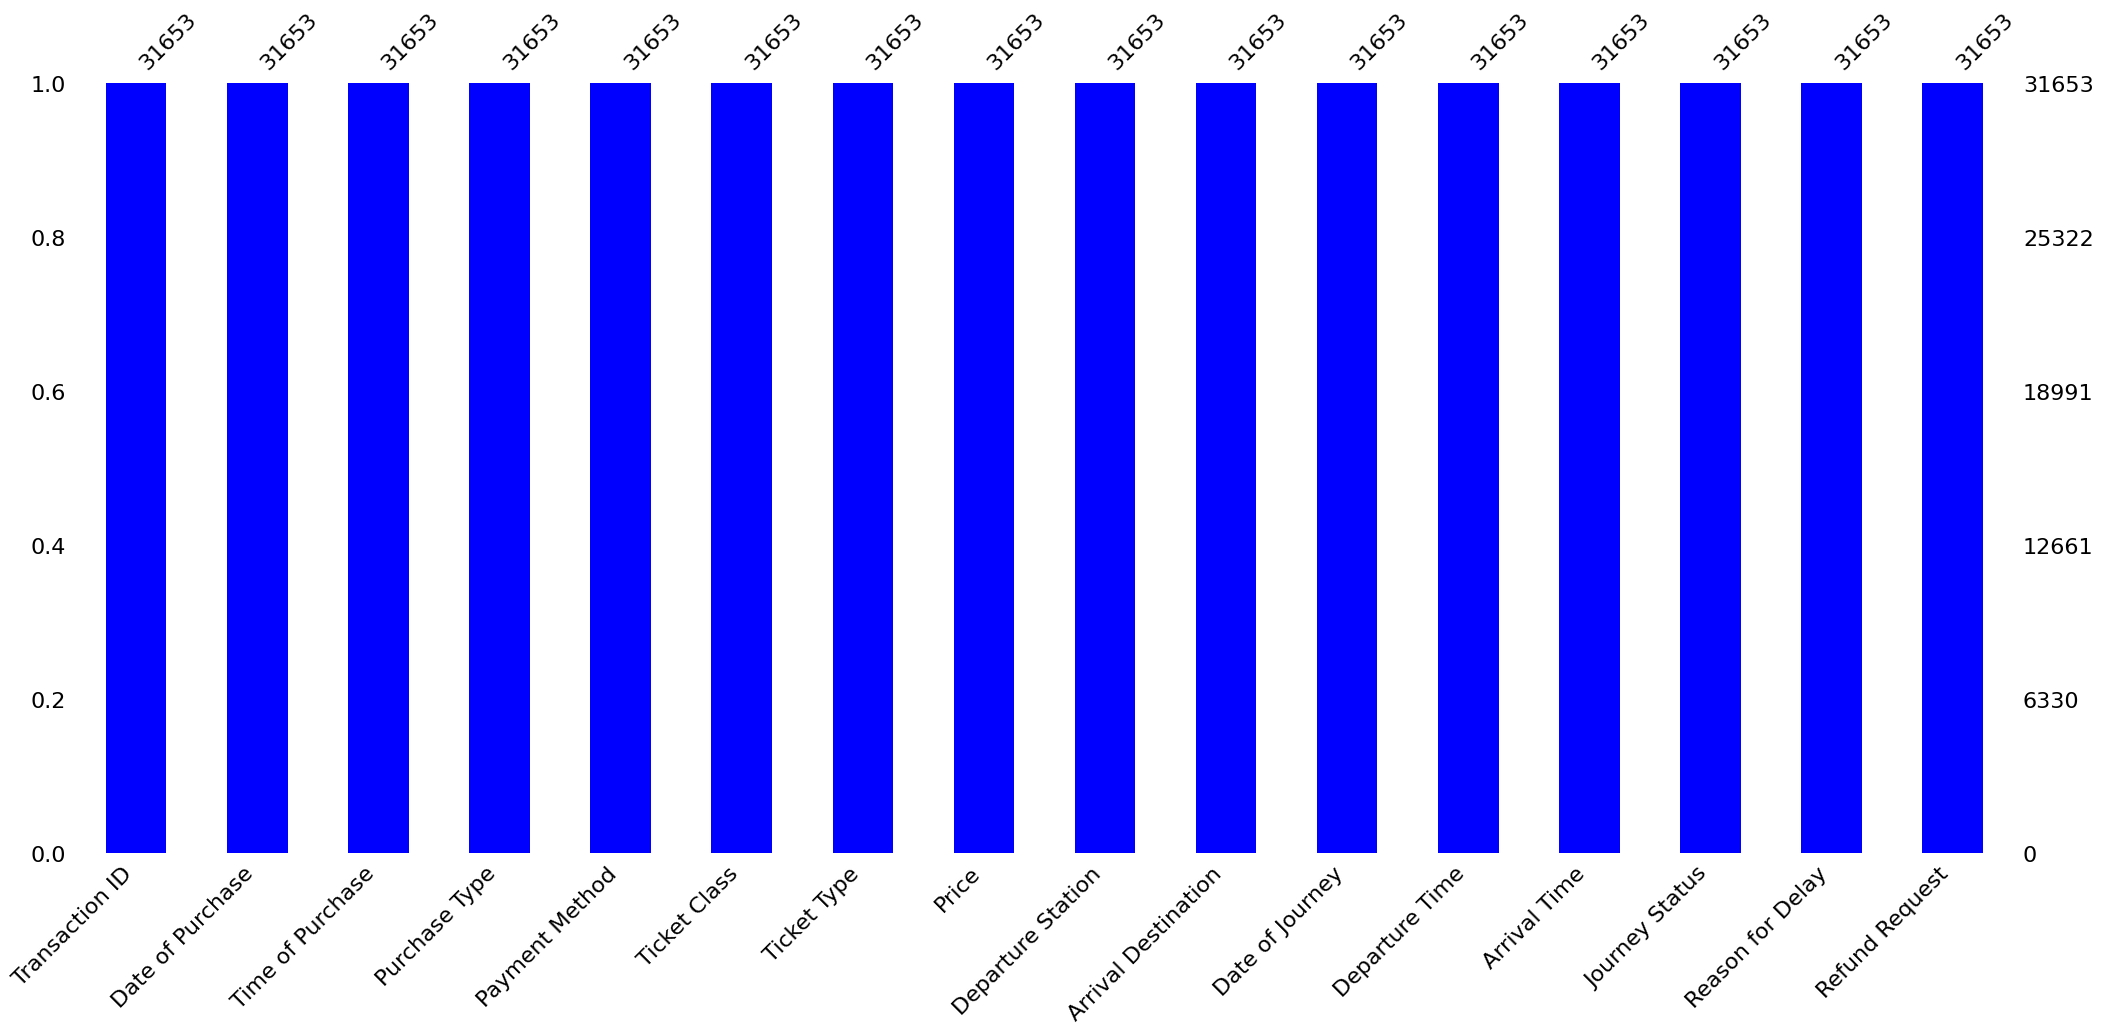

In [25]:
msno.bar(uk_ride_data, color = 'blue');

In [26]:
uk_ride_data.isnull().sum()

Transaction ID         0
Date of Purchase       0
Time of Purchase       0
Purchase Type          0
Payment Method         0
Ticket Class           0
Ticket Type            0
Price                  0
Departure Station      0
Arrival Destination    0
Date of Journey        0
Departure Time         0
Arrival Time           0
Journey Status         0
Reason for Delay       0
Refund Request         0
dtype: int64

In [27]:
for col in uk_ride_data.columns:
    if col not in ['Price', 'Transaction ID', 'Date of Purchase', 'Time of Purchase', 'Date of Journey', 'Departure Time', 'Arrival Time', 'Actual Arrival Time']:
        print("\n", col)
        print(uk_ride_data[col].unique())
        print()
        print("Inconsistencies successfully handled")


 Purchase Type
['Online' 'Station']

Inconsistencies successfully handled

 Payment Method
['Contactless' 'Credit Card' 'Debit Card']

Inconsistencies successfully handled

 Ticket Class
['Standard' 'First Class']

Inconsistencies successfully handled

 Ticket Type
['Advance' 'Off-Peak' 'Anytime']

Inconsistencies successfully handled

 Departure Station
['London Paddington' 'London Kings Cross' 'Liverpool Lime Street'
 'London Euston' 'York' 'Manchester Piccadilly' 'Birmingham New Street'
 'London St Pancras' 'Oxford' 'Reading' 'Edinburgh Waverley'
 'Bristol Temple Meads']

Inconsistencies successfully handled

 Arrival Destination
['Liverpool Lime Street' 'York' 'Manchester Piccadilly' 'Reading'
 'London Euston' 'Oxford' 'Durham' 'London St Pancras'
 'Birmingham New Street' 'London Paddington' 'Bristol Temple Meads'
 'Tamworth' 'London Waterloo' 'Sheffield' 'Wolverhampton' 'Leeds'
 'Stafford' 'Doncaster' 'Swindon' 'Nottingham' 'Peterborough' 'Edinburgh'
 'Crewe' 'London Kings Cross'

#### Q1: What is the distribution of the train price?

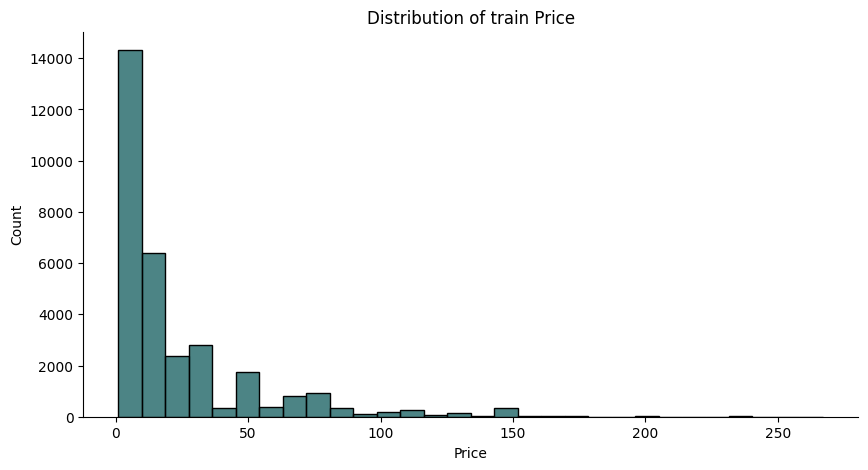

In [28]:
colors =['#e8eeed','#105b5c']
plt.figure(figsize =(10, 5))
sns.histplot(uk_ride_data, x ='Price', bins = 30, color ='#105b5c')
plt.title("Distribution of train Price")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 1.png",dpi=300, bbox_inches="tight")
plt.show()

- Train price is rightly skewed and concentrated betweem 0 and 50 USD per ride

#### Q2: Departure station with most train passengers?

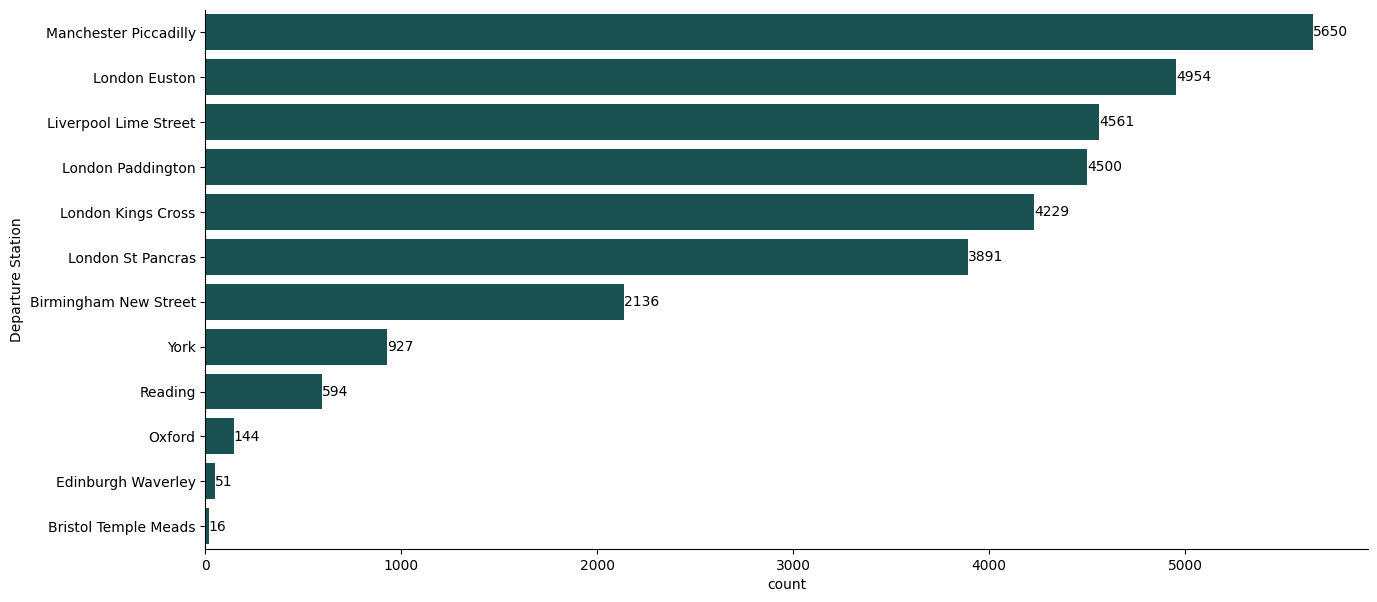

In [29]:
fig, ax =plt.subplots(figsize =(15, 7))
ax = sns.countplot(uk_ride_data['Departure Station'], order =uk_ride_data['Departure Station'].value_counts().index, color ='#105b5c')
values =order =uk_ride_data['Departure Station'].value_counts().values
ax.bar_label(container =ax.containers[0], labels = values)
plt.title("")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 2.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights** 

- It very clear that Manchester Station is doing amazing well with regard to the number of train trips, followed by Euston London station and the leaste performing station is Bristol Temple meads

#### Q3: Which Payment method is the most used?

In [30]:
uk_ride_data['Payment Method'].value_counts(normalize =True)

Payment Method
Credit Card    0.604556
Contactless    0.342274
Debit Card     0.053170
Name: proportion, dtype: float64

Over 61% of the payment were recieved through Credit card method and then Contactless method

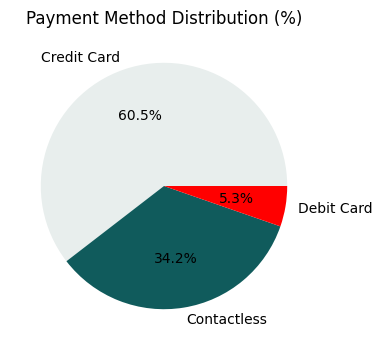

In [31]:
fig, axes = plt.subplots(figsize=(8, 4))

plt.pie(uk_ride_data['Payment Method'].value_counts(), labels=['Credit Card', 'Contactless','Debit Card'], autopct='%1.1f%%', colors =['#e8eeed','#105b5c', 'red'])
plt.title('Payment Method Distribution (%)')
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 3.png",dpi=300, bbox_inches="tight");

#### Q4: Distribution of the train ticket type: who are our most customers?

In [32]:
uk_ride_data['Ticket Type'].value_counts()

Ticket Type
Advance     17561
Off-Peak     8752
Anytime      5340
Name: count, dtype: int64

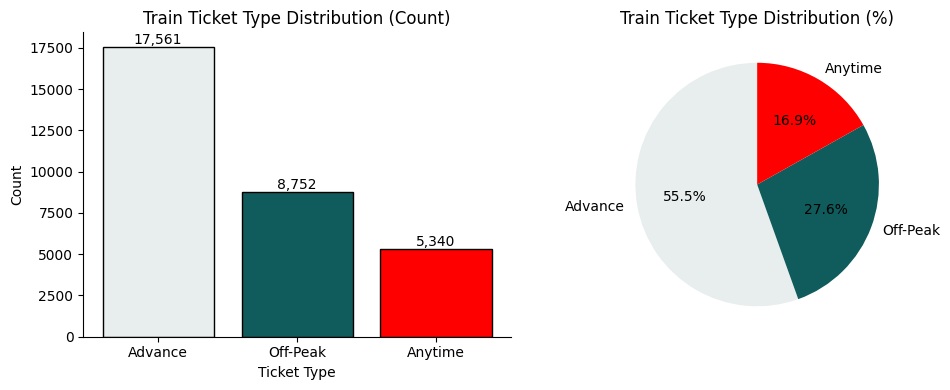

In [33]:
# Count and percentage of train ticket type
ticket_counts = uk_ride_data['Ticket Type'].value_counts()
ticket_pct = uk_ride_data['Ticket Type'].value_counts(normalize=True) * 100

# # Print counts and percentages
# for ticket_type in ticket_counts.index:
#     print(f"{ticket_type}: {ticket_counts[ticket_type]:,} ({ticket_pct[ticket_type]:.1f}%)")


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#e8eeed', '#105b5c', 'red']

# Bar chart
bars = axes[0].bar(
    ticket_counts.index,
    ticket_counts.values,
    color=colors[:len(ticket_counts)],
    edgecolor='black'
)

axes[0].set_title('Train Ticket Type Distribution (Count)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Ticket Type')

# Add labels on bars
axes[0].bar_label(bars, labels=[f'{v:,}' for v in ticket_counts.values])

# Pie chart
axes[1].pie(
    ticket_counts.values,
    labels=ticket_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(ticket_counts)],
    startangle=90
)

axes[1].set_title('Train Ticket Type Distribution (%)')

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 4.png",dpi=300, bbox_inches="tight")
plt.show()

The most in demand train tickets id the advance type followed bt off-Peak type and the Anytime comes last

#### Q5: Top 5 reasons for train delay:What are the main contributing factors?

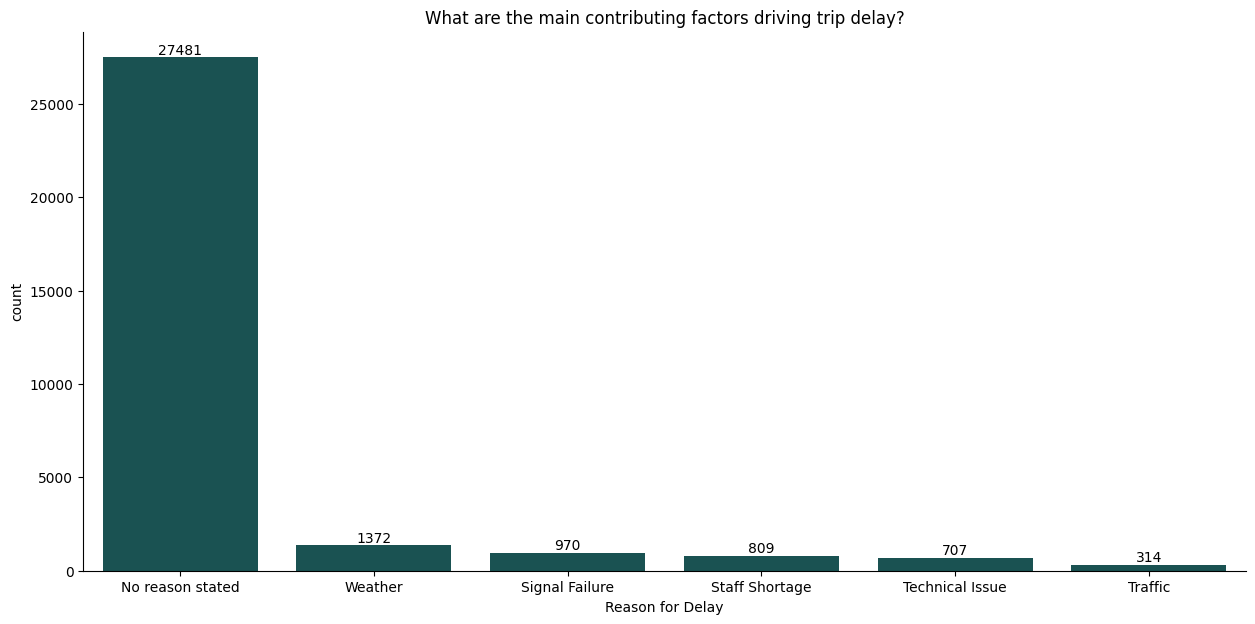

In [34]:
fig, ax =plt.subplots(figsize =(15, 7))
ax = sns.countplot(x =uk_ride_data['Reason for Delay'], order =uk_ride_data['Reason for Delay'].value_counts().index, color ='#105b5c')
values =order =uk_ride_data['Reason for Delay'].value_counts().values
ax.bar_label(container =ax.containers[0], labels = values)
plt.title("What are the main contributing factors driving trip delay?")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 5.png",dpi=300, bbox_inches="tight")
plt.show()

It is very sad that the major factors driving trip delays has not be mentioned. Recalled we filled the missing rows with "No reason stated" since that was recorded "null". So aside the no reason stated the Weather is a major driver of trip delay followef by Signal failure. When the official/workers are not able to offer signal to help trip success.

#### Q6: What is the overall status of the journey: What is the on-time performance?

In [35]:
uk_ride_data['Journey Status'].value_counts()

Journey Status
On Time      27481
Delayed       2292
Cancelled     1880
Name: count, dtype: int64

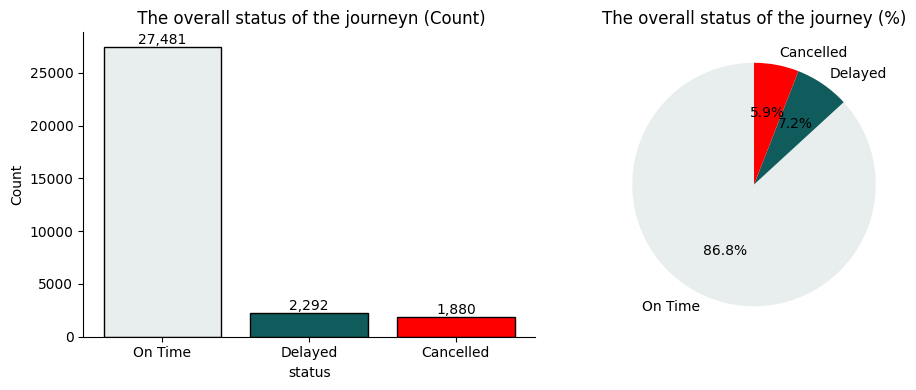

In [36]:
jou_counts = uk_ride_data['Journey Status'].value_counts()
pct_counts = uk_ride_data['Journey Status'].value_counts(normalize =True) *100


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#e8eeed', '#105b5c', 'red']

# Bar chart
bars = axes[0].bar(
    jou_counts.index,
    jou_counts.values,
    color=colors[:len(jou_counts)],
    edgecolor='black'
)

axes[0].set_title(' The overall status of the journeyn (Count)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('status')

# Add labels on bars
axes[0].bar_label(bars, labels=[f'{v:,}' for v in jou_counts.values])

# Pie chart
axes[1].pie(
    jou_counts.values,
    labels=jou_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(jou_counts)],
    startangle=90
)

axes[1].set_title('The overall status of the journey (%)')

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 6.png",dpi=300, bbox_inches="tight")
plt.show()


**Insight**

- Good news for Uk Train Ride as large share of their trip arrive on time, with only 7.2% delayed train trips and omly about 6% train trip totally cancelled. Efficiency could be improve to reduced Delayed trip and cancellation risk

In [37]:
# Here, we are tryin to convert these features/columns to datetime
uk_ride_data['Time of PurchaseDeparture Time'] = pd.to_datetime(uk_ride_data['Time of Purchase'], errors='coerce')
uk_ride_data['Date of Journey'] = pd.to_datetime(uk_ride_data['Date of Journey'], errors='coerce')
uk_ride_data['Departure Time'] = pd.to_datetime(uk_ride_data['Departure Time'], errors='coerce')
uk_ride_data['Arrival Time'] = pd.to_datetime(uk_ride_data['Arrival Time'], errors='coerce')
uk_ride_data['Time of Purchase'] = pd.to_datetime(uk_ride_data['Time of Purchase'], errors='coerce')

In [38]:
# We are trying to group the ride by routes in order to get the most popular routes
uk_ride_data['Route'] = uk_ride_data['Departure Station'] + " → " + uk_ride_data['Arrival Destination']
route_counts = uk_ride_data['Route'].value_counts()
valid_routes = route_counts[route_counts > 30].index
df_filtered = uk_ride_data[uk_ride_data['Route'].isin(valid_routes)]

#### Q7: What are the most popular routes?

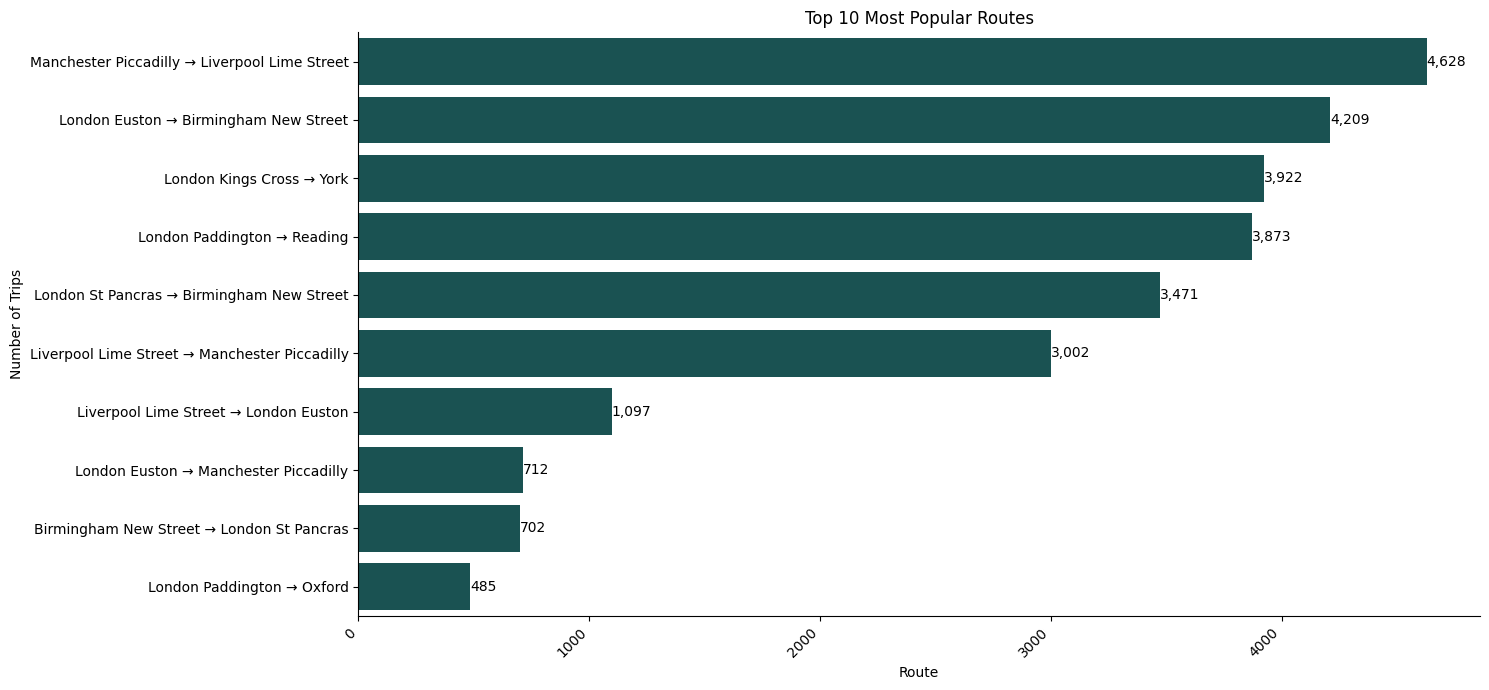

In [39]:
# Get top 10 most popular routes
top_10_routes = df_filtered['Route'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(15, 7))

sns.countplot(
    data=df_filtered[df_filtered['Route'].isin(top_10_routes.index)],
    y='Route',
    order=top_10_routes.index,
    color='#105b5c',
    ax=ax
)

# Add labels
ax.bar_label(
    ax.containers[0],
    labels=[f'{v:,}' for v in top_10_routes.values]
)

ax.set_title("Top 10 Most Popular Routes")
ax.set_xlabel("Route")
ax.set_ylabel("Number of Trips")

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 7.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights** 

- The most popular routes is from Manchester Piccadilly to Liverpool Lime Street and the second populous is London Euston to BirmingHam New Streat

#### Q8: What are the most expensive vs Cheapest routes?

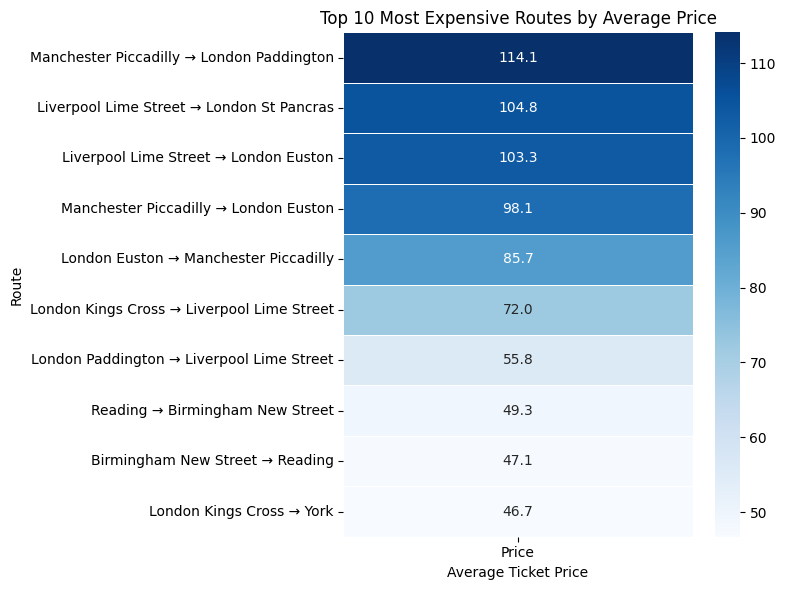

In [40]:
expensive = (
    df_filtered
    .groupby('Route')['Price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(1)
    .to_frame()
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    expensive,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidth=0.5
)

plt.title('Top 10 Most Expensive Routes by Average Price')
plt.xlabel('Average Ticket Price')
plt.ylabel('Route')

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 8.png",dpi=300, bbox_inches="tight")
plt.show()

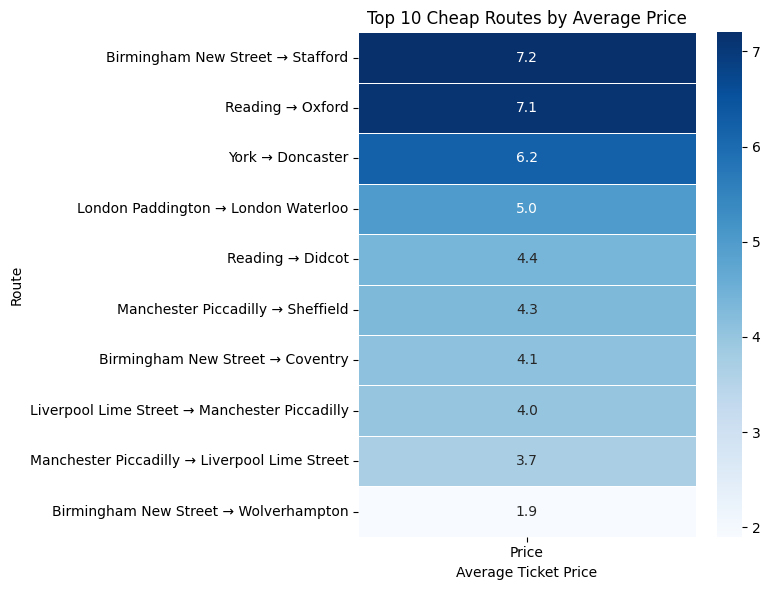

In [41]:
cheap = (
    df_filtered
    .groupby('Route')['Price']
    .mean()
    .sort_values(ascending=False)
    .tail(10)
    .round(1)
    .to_frame()
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cheap,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidth=0.5
)

plt.title('Top 10 Cheap Routes by Average Price')
plt.xlabel('Average Ticket Price')
plt.ylabel('Route')

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 9.png",dpi=300, bbox_inches="tight")
plt.show()

#### Q9: What are the peak travel times?

In [42]:
uk_ride_data.head()
# Extract hour of the day
uk_ride_data['Hour_of_day'] = uk_ride_data['Departure Time'].dt.hour

# Extract day of the week name
uk_ride_data['Day_of_week'] = uk_ride_data['Time of PurchaseDeparture Time'].dt.day_name()

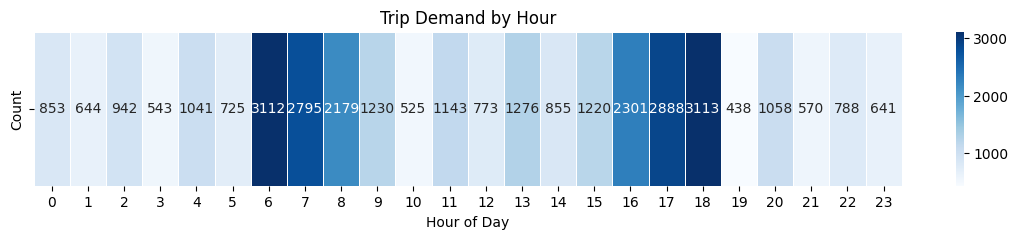

In [43]:
# Count trips by hour
monday_hour_counts = uk_ride_data['Hour_of_day'].value_counts().sort_index()

# Convert to dataframe for heatmap
monday_heatmap = monday_hour_counts.to_frame(name='Count').T

plt.figure(figsize=(14, 2))

sns.heatmap(
    monday_heatmap,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidth=0.5
)

plt.title('Trip Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 10.png",dpi=300, bbox_inches="tight")
plt.show()

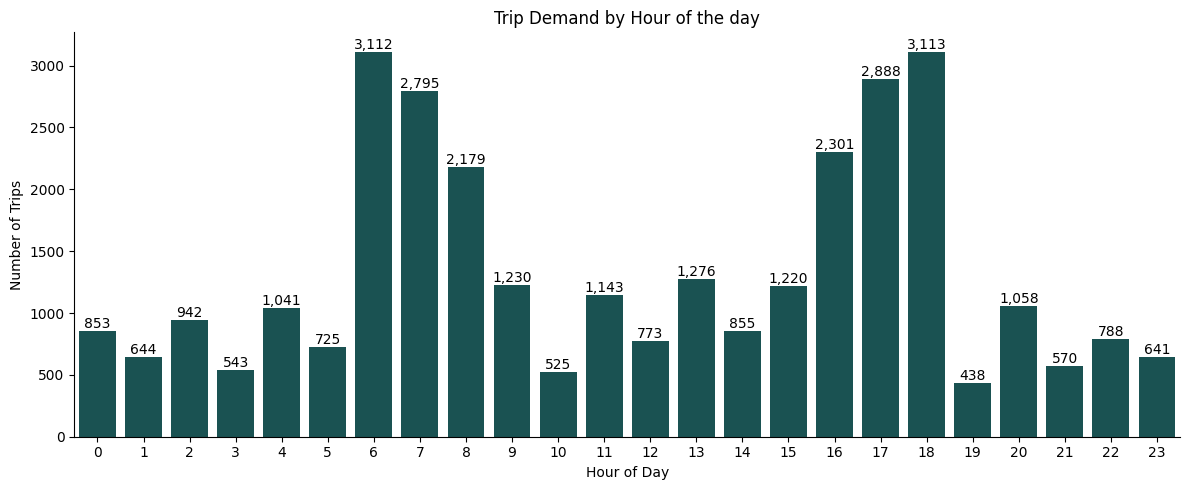

In [44]:
monday_hour_counts = uk_ride_data['Hour_of_day'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    x=monday_hour_counts.index,
    y=monday_hour_counts.values,
    color='#105b5c',
    ax=ax
)

ax.bar_label(
    ax.containers[0],
    labels=[f'{v:,}' for v in monday_hour_counts.values]
)

ax.set_title('Trip Demand by Hour of the day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Trips')

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 11.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights**

Trip demand is strongly concentrated around two peak periods: the **morning rush hour** and the **evening rush hour**. The highest demand occurs at **6 AM with 3,112 trips** and **6 PM with 3,113 trips**, showing that passenger movement is heavily driven by work and commute patterns.

Demand remains high between **6 AM and 8 AM**, then drops sharply after 9 AM, with one of the lowest points at **10 AM with 525 trips**. A second major surge begins from **4 PM**, rising strongly through **5 PM and 6 PM**, before falling sharply at **7 PM with only 438 trips**.

Overall, the chart suggests that train activity is busiest during commute hours, while late night, early morning, and mid-morning periods record much lower demand.


#### Q10: How does revenue vary by ticket types and classes?

In [45]:
uk_ride_data.head(2)

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Journey Status,Reason for Delay,Refund Request,Time of PurchaseDeparture Time,Route,Hour_of_day,Day_of_week
0,da8a6ba8-b3dc-4677-b176,2023-12-08,2026-06-22 12:41:11,Online,Contactless,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,2026-06-22 11:00:00,2026-06-22 13:30:00,On Time,No reason stated,No,2026-06-22 12:41:11,London Paddington → Liverpool Lime Street,11,Monday
1,b0cdd1b0-f214-4197-be53,2023-12-16,2026-06-22 11:23:01,Station,Credit Card,Standard,Advance,23,London Kings Cross,York,2024-01-01,2026-06-22 09:45:00,2026-06-22 11:35:00,Delayed,Signal Failure,No,2026-06-22 11:23:01,London Kings Cross → York,9,Monday


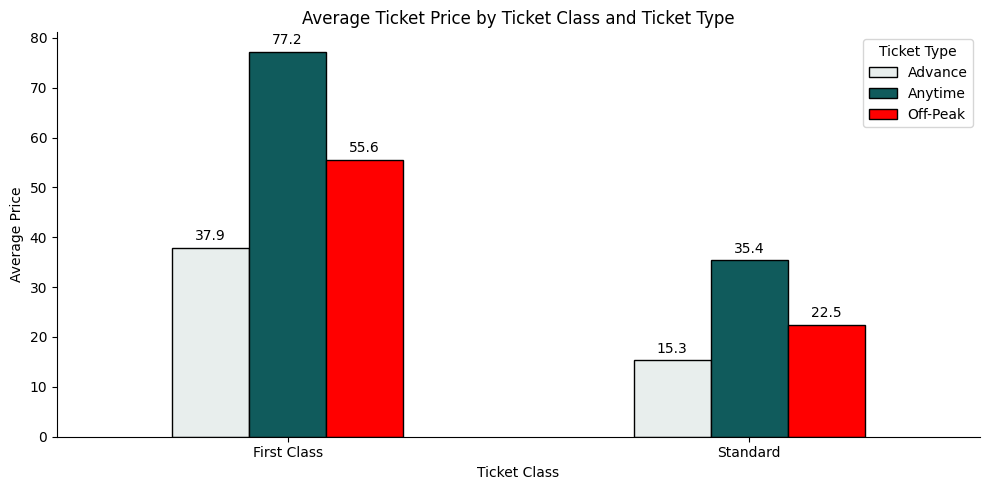

In [46]:
avg_price = (
    uk_ride_data
    .groupby(['Ticket Class', 'Ticket Type'])['Price']
    .mean()
    .unstack()
    .round(2)
)

ax = avg_price.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='black',
    color=['#e8eeed', '#105b5c', 'red']
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

plt.title('Average Ticket Price by Ticket Class and Ticket Type')
plt.xlabel('Ticket Class')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.legend(title='Ticket Type')
sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 12.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights:**

First Class tickets are consistently more expensive than Standard tickets across all ticket types, showing a clear price premium for higher-class travel.

**Anytime tickets have the highest average price** in both classes, with First Class Anytime costing about **77.2**, while Standard Anytime costs about **35.4**. This suggests that flexibility comes at a strong premium.

**Advance tickets are the cheapest option** in both First Class and Standard, indicating that passengers who book earlier enjoy lower fares.

Off-Peak tickets sit between Advance and Anytime, making them a more affordable option for passengers who can travel outside peak periods.

Overall, ticket price is strongly influenced by both **ticket class** and **ticket type**, with First Class Anytime being the most expensive and Standard Advance being the cheapest.


#### Q11: How does train price vary across different times of the day?

In [47]:
hourly_summary = (
    uk_ride_data
    .groupby('Hour_of_day')
    .agg(
        avg_price=('Price', 'mean'),
        trip_count=('Price', 'count')
    )
    .reset_index()
    .round(2)
)

hourly_summary.head(1)

,Hour_of_day,avg_price,trip_count
0,0,14.55,853


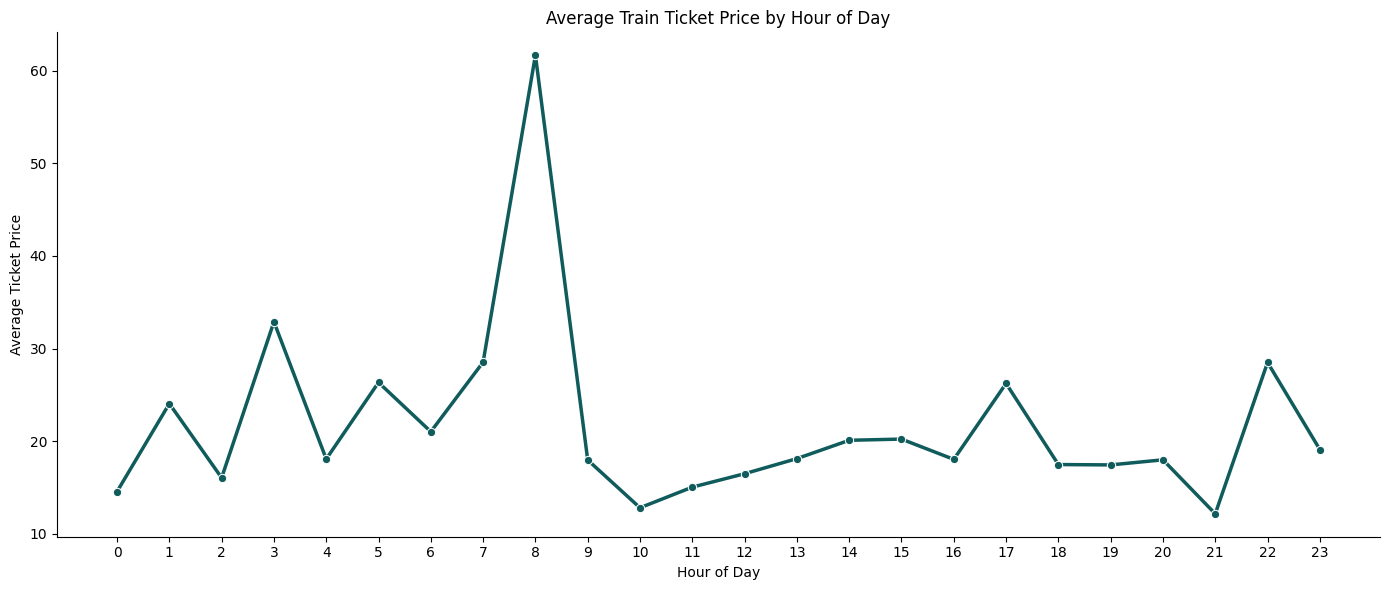

In [48]:
hourly_price = (
    uk_ride_data
    .groupby('Hour_of_day')['Price']
    .mean()
    .reset_index()
    .round(2)
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=hourly_price,
    x='Hour_of_day',
    y='Price',
    marker='o',
    color='#105b5c',
    ax=ax,
    linewidth =2.5
)

# for x, y in zip(hourly_price['Hour_of_day'], hourly_price['Price']):
#     ax.text(x, y, f'£{y:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Train Ticket Price by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Ticket Price')

plt.xticks(range(0, 24))
sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 21\UK Ride\C 13.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights:**

Average train ticket prices vary noticeably across the day, with the strongest price spike occurring at **8 AM**, where the average ticket price rises to about **£62**. This suggests that morning rush-hour travel may attract higher fares, possibly due to stronger demand, more Anytime ticket purchases, or a higher share of First Class tickets.

Prices are relatively moderate across most hours, generally staying between **£15 and £30**. The lowest average prices appear around **10 AM** and **9 PM**, indicating cheaper travel during off-peak periods.

Overall, the chart suggests that ticket prices are not constant throughout the day. Prices are highest during peak travel periods, especially the morning rush, while off-peak hours tend to offer lower average fares.


#### **Conclusion and Recommendations**

#### **Conclusion**

The analysis shows that UK train rides are generally performing well, with most trips arriving on time and only a small share of journeys delayed or cancelled. However, the data also reveals important areas for improvement. Passenger demand is highly concentrated during morning and evening commute hours, ticket prices vary strongly by time of day, ticket class, and ticket type, and some stations and routes clearly perform better than others.

Manchester Station and London Euston stand out as high-activity stations, while Bristol Temple Meads records weaker trip activity. Advance tickets are the most demanded, showing that many passengers prefer cheaper early-booking options. At the same time, Anytime and First Class tickets attract higher prices, especially during peak periods. Delays are relatively low, but weather and signal failures remain key operational risks that can affect customer satisfaction and service reliability.

Overall, the business opportunity is clear: UK rail operators can improve performance by using demand patterns, pricing behaviour, and delay causes to make better decisions around scheduling, pricing, route management, and customer experience.

#### **Recommendations**

**1. Improve peak-hour capacity and scheduling**
Since trip demand peaks strongly around **6 AM and 6 PM**, operators should increase train availability, carriage capacity, and staff support during these periods. High-demand routes such as **Manchester Piccadilly to Liverpool Lime Street** and **London Euston to Birmingham New Street** should receive closer scheduling attention to reduce congestion and improve passenger flow.

**2. Strengthen delay prevention and service reliability**
Although most trips arrive on time, delays and cancellations still affect customer experience. Since weather and signal failures are major known delay drivers, operators should invest in better signal maintenance, real-time disruption monitoring, and contingency planning during bad weather. The “No reason stated” delay records should also be improved so the business can clearly understand and address the real causes of service disruption.

**3. Optimize pricing and ticket strategy**
Ticket prices are highest during peak travel periods, especially around **8 AM**, while Advance tickets remain the most demanded and cheapest option. Operators should use this insight to promote early booking, maintain attractive Advance fares, and apply smarter peak/off-peak pricing. First Class and Anytime tickets can remain premium products, but pricing should be monitored carefully to avoid discouraging passengers during high-demand periods.
